# Phase 3 — End-to-End Differentiable Optimization (OptNet): Interactive Demo

**Author:** Principal AI Researcher, Infosys Procurement Agent  
**Reference:** `KnowledgeBase/project_scaffold/ai_models/comparasion_scoring_model/phase3_optnet_e2e.md`  
**Status:** Phase 3 — Decision-aware learning via implicit differentiation of KKT conditions

---

## The Predict-Then-Optimize Gap

Phase 1 used hand-coded weights. Phase 2 learned weights from override events using ranking loss. Both share a structural flaw: **they optimise for prediction accuracy, not decision quality.**

Consider a procurement scenario where the buyer must allocate a single order across multiple suppliers under a per-supplier capacity cap. The total cost depends on the *allocation* $\mathbf{z}$, which is the output of an LP solver:

$$\mathbf{z}^*(\mathbf{c}) = \arg\min_{\mathbf{z} \in \mathcal{F}}\ \mathbf{c}^\top \mathbf{z}$$

A two-stage "predict-then-optimize" pipeline trains an ML model to predict $\mathbf{c}$ via Mean-Squared Error, then plugs $\hat{\mathbf{c}}$ into the LP. **The MSE objective treats every prediction error as equally important**, but a 5% error on the 3rd-cheapest supplier — exactly the one on the LP's boundary — can flip the optimal allocation, while a 50% error on a never-selected supplier costs nothing.

## The Decision-Aware Solution

Phase 3 trains the encoder $f_\theta$ end-to-end against **financial regret**:

$$\mathcal{L}_{\text{regret}}(\theta) = \mathbb{E}\!\left[\,\mathbf{c}_{\text{true}}^{\top}\,\mathbf{z}^*(\mathbf{c}_\theta) - \mathbf{c}_{\text{true}}^{\top}\,\mathbf{z}^*(\mathbf{c}_{\text{true}})\,\right]$$

This is the realised cost of using the model's allocation, minus the cost of the oracle allocation. To compute $\partial \mathcal{L}/\partial \theta$, gradients must flow **through** the LP solver — which is non-differentiable in the classical sense. The OptNet framework (Amos & Kolter, 2017) and `cvxpylayers` (Agrawal et al., 2019) solve this via **implicit differentiation of the KKT conditions**:

$$\frac{\partial \mathbf{z}^*}{\partial \mathbf{c}} = -\,K_{\text{sym}}^{-1} \begin{bmatrix} I \\ 0 \\ 0 \end{bmatrix}$$

where $K_{\text{sym}}$ is a structured block matrix built from the LP's primal/dual variables and active constraint set. PyTorch autograd composes this with $\partial \mathbf{c}_\theta / \partial \theta$ to produce a single, end-to-end gradient.

## Pipeline

```
          features X                     ground-truth costs c_true
             │                              (observed post-delivery)
             ▼                                       │
        ┌──────────┐                                 │
        │  MLP fθ  │ ──────► c_θ ─┐                  │
        └──────────┘                │                │
                                    ▼                │
                            ┌───────────────┐        │
                            │  CvxpyLayer   │        │
                            │   LP solver   │        │
                            └───────┬───────┘        │
                                    ▼                │
                                  z_θ ───────► c_true^T (z_θ − z_true) = REGRET
                                    ▲                                       │
                          ∂z*/∂c via                                        │
                          K_sym^-1                                          │
                                    │                                       ▼
                                    └─────── ∂L/∂θ ◄─────────── loss.backward()
```

## Notebook Plan

| Cell | Stage | Description |
|------|-------|-------------|
| 1 | Imports | torch, cvxpy, cvxpylayers, numpy, matplotlib |
| 2 | Data | Synthetic procurement sessions with hidden cost function |
| 3 | LP | DPP-compliant CVXPY problem + `CvxpyLayer` |
| 4 | Encoder | 2-layer MLP `f_θ : X → c_θ` + AdamW |
| 5 | Loss | Decision regret with offline `z_true` |
| 6 | Train | 60 epochs end-to-end through KKT |
| 7 | Analysis | Loss curve, allocation comparison, MSE baseline showdown |

In [1]:
# Cell 1 — Imports
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer

torch.manual_seed(7)
np.random.seed(7)

print(f"PyTorch  : {torch.__version__}")
print(f"NumPy    : {np.__version__}")
print(f"CVXPY    : {cp.__version__}")

PyTorch  : 2.11.0+cu130
NumPy    : 2.4.4
CVXPY    : 1.8.2


## Cell 2 — Procurement Environment & Data

### Session Layout

Each procurement session has $n = 5$ candidate suppliers. Each supplier $i$ has a feature vector $\mathbf{x}_i \in \mathbb{R}^3$:

| Index | Feature | Range |
|-------|---------|-------|
| 0 | $x_{\text{quality}}$ | $[0.2, 1.0]$ |
| 1 | $x_{\text{speed}}$ | $[0.2, 1.0]$ |
| 2 | $x_{\text{risk}}$ | $[0.2, 1.0]$ |

### The Hidden Cost Function (the NN must learn this)

$$c_{\text{true},i} = 100 + 50\,x_{\text{quality}} + 30\,x_{\text{speed}} - 40\,x_{\text{risk}} + 25\,(x_{\text{quality}} \cdot x_{\text{speed}}) + \varepsilon_i,\quad \varepsilon_i \sim \mathcal{N}(0, 5^2)$$

The interaction term $x_{\text{quality}} \cdot x_{\text{speed}}$ is non-linear — a linear regressor cannot recover it, so the 2-layer MLP is the minimal sufficient model class.

We sample $N_{\text{train}} = 60$ training sessions and $N_{\text{test}} = 20$ test sessions. Train sessions feed gradient updates; test sessions measure generalisation regret.

In [2]:
# Cell 2 — Generate procurement sessions with the hidden cost function

N_SUPPLIERS = 5
N_FEATURES  = 3
N_TRAIN     = 60
N_TEST      = 20
MAX_ALLOC   = 0.4   # per-supplier capacity cap (sum=1, 5 suppliers, 0.4 → split orders)


def generate_session(rng: np.random.Generator):
    """Sample one procurement session: feature matrix X (n,3) + ground-truth costs c (n,)."""
    X = rng.uniform(0.2, 1.0, size=(N_SUPPLIERS, N_FEATURES))
    quality, speed, risk = X[:, 0], X[:, 1], X[:, 2]
    c = (100.0
         + 50.0 * quality
         + 30.0 * speed
         - 40.0 * risk
         + 25.0 * (quality * speed)            # ← non-linear interaction
         + rng.normal(0, 5.0, size=N_SUPPLIERS))
    return X.astype(np.float32), c.astype(np.float32)


rng = np.random.default_rng(7)

X_train_np = np.zeros((N_TRAIN, N_SUPPLIERS, N_FEATURES), dtype=np.float32)
c_train_np = np.zeros((N_TRAIN, N_SUPPLIERS),             dtype=np.float32)
for i in range(N_TRAIN):
    X_train_np[i], c_train_np[i] = generate_session(rng)

X_test_np = np.zeros((N_TEST, N_SUPPLIERS, N_FEATURES), dtype=np.float32)
c_test_np = np.zeros((N_TEST, N_SUPPLIERS),             dtype=np.float32)
for i in range(N_TEST):
    X_test_np[i], c_test_np[i] = generate_session(rng)

# Convert to torch tensors
X_train = torch.tensor(X_train_np)
c_train = torch.tensor(c_train_np)
X_test  = torch.tensor(X_test_np)
c_test  = torch.tensor(c_test_np)

print(f"Generated {N_TRAIN} train + {N_TEST} test sessions")
print(f"  X_train shape: {tuple(X_train.shape)}")
print(f"  c_train shape: {tuple(c_train.shape)}")
print()
print("Sample session 0:")
print(f"  Features [quality, speed, risk]:\n{X_train_np[0]}")
print(f"  True costs c_true: {c_train_np[0]}")
print(f"  Cost spread: min={c_train_np[0].min():.2f}, max={c_train_np[0].max():.2f}, "
      f"Δ={c_train_np[0].max() - c_train_np[0].min():.2f}")

Generated 60 train + 20 test sessions
  X_train shape: (60, 5, 3)
  c_train shape: (60, 5)

Sample session 0:
  Features [quality, speed, risk]:
[[0.7000764  0.91777104 0.82054853]
 [0.38016576 0.44013304 0.89884275]
 [0.20421225 0.8569827  0.83765554]
 [0.574348   0.44242594 0.4227405 ]
 [0.40389568 0.556061   0.6036386 ]]
  True costs c_true: [149.25427  93.72058 104.50095 121.9271  111.89815]
  Cost spread: min=93.72, max=149.25, Δ=55.53


## Cell 3 — Differentiable LP Solver via `cvxpylayers`

### Procurement Allocation LP

Given a cost vector $\mathbf{c} \in \mathbb{R}^n$, find the allocation $\mathbf{z} \in [0,1]^n$ that minimises total cost subject to capacity caps:

$$\begin{aligned}
\mathbf{z}^*(\mathbf{c}) = \arg\min_{\mathbf{z}}\quad & \mathbf{c}^\top \mathbf{z} \\
\text{s.t.}\quad & \mathbf{1}^\top \mathbf{z} = 1 & \text{(full allocation)} \\
                  & 0 \le z_i \le \bar{z} = 0.4 & \text{(per-supplier cap)}
\end{aligned}$$

With $n = 5$ and $\bar{z} = 0.4$, the optimal solution always splits the order across the **3 cheapest suppliers** (the third receives the residual $1 - 2 \cdot 0.4 = 0.2$). Small changes in $\mathbf{c}$ that re-rank the 3rd vs. 4th cheapest supplier flip $\mathbf{z}^*$ — exactly where decision-aware learning has the most leverage.

### KKT Conditions

Forming the Lagrangian with multipliers $\nu \in \mathbb{R}$ (equality) and $\lambda \in \mathbb{R}^{2n}_{\ge 0}$ (inequalities):

$$\mathcal{L}(\mathbf{z}, \nu, \lambda) = \mathbf{c}^\top \mathbf{z} + \nu(\mathbf{1}^\top \mathbf{z} - 1) + \lambda^\top G\mathbf{z}$$

Stationarity gives $\mathbf{c} + \nu \mathbf{1} + G^\top \lambda = 0$. Together with primal/dual feasibility and complementary slackness, these conditions implicitly define $\mathbf{z}^*(\mathbf{c})$. The Jacobian $\partial \mathbf{z}^*/\partial \mathbf{c}$ is obtained by solving:

$$K_{\text{sym}}\,\begin{bmatrix} d\mathbf{z} \\ d\nu \\ d\lambda \end{bmatrix} = -\begin{bmatrix} d\mathbf{c} \\ 0 \\ 0 \end{bmatrix},\quad K_{\text{sym}} = \begin{bmatrix} 0 & \mathbf{1} & G^\top \\ \mathbf{1}^\top & 0 & 0 \\ \mathrm{diag}(\lambda^*) G & 0 & \mathrm{diag}(G\mathbf{z}^* - \mathbf{h}) \end{bmatrix}$$

`cvxpylayers` performs this matrix solve internally during `loss.backward()` — we never see it.

### DPP Compliance

`cvxpylayers` requires **Disciplined Parameterized Programming**: parameters appear at most linearly. Our objective `c @ z` is the inner product of a `Parameter` and a `Variable` — affine in both, fully DPP-compliant.

In [3]:
# Cell 3 — Define the CVXPY LP and wrap it as a differentiable layer

n = N_SUPPLIERS

# Decision variable: allocation fractions z_i
z_var   = cp.Variable(n, nonneg=True)
# Parameter: predicted cost vector c_θ (filled in by the NN at forward time)
c_param = cp.Parameter(n)

constraints = [
    cp.sum(z_var) == 1.0,       # full-allocation
    z_var <= MAX_ALLOC,          # per-supplier cap (z_var >= 0 from nonneg=True)
]

objective = cp.Minimize(c_param @ z_var)
problem   = cp.Problem(objective, constraints)

# DPP / DCP sanity check — this MUST pass for cvxpylayers
assert problem.is_dpp(), "LP is not DPP-compliant — cvxpylayers will fail"
assert problem.is_dcp(), "LP is not DCP-compliant — CVXPY cannot solve it"
print(f"  problem.is_dpp() = {problem.is_dpp()}")
print(f"  problem.is_dcp() = {problem.is_dcp()}")

# Wrap as a differentiable PyTorch layer
cvxpy_layer = CvxpyLayer(problem, parameters=[c_param], variables=[z_var])
print("  CvxpyLayer wrapped successfully")

# Smoke test: solve the LP for a sample cost vector via the layer
with torch.no_grad():
    c_sample = c_train[0]  # (5,)
    (z_sample,) = cvxpy_layer(c_sample)
print(f"\nSmoke test on session 0:")
print(f"  c_true        = {c_sample.numpy()}")
print(f"  z*(c_true)    = {z_sample.numpy()}")
print(f"  sum(z*)       = {z_sample.sum().item():.4f}  (must be 1.0)")
print(f"  max(z*)       = {z_sample.max().item():.4f}  (must be ≤ 0.4)")
print(f"  realised cost = {(c_sample * z_sample).sum().item():.4f}")

  problem.is_dpp() = True
  problem.is_dcp() = True
  CvxpyLayer wrapped successfully

Smoke test on session 0:
  c_true        = [149.25427  93.72058 104.50095 121.9271  111.89815]
  z*(c_true)    = [9.96042922e-09 4.00000046e-01 3.99999995e-01 1.22218060e-08
 1.99999937e-01]
  sum(z*)       = 1.0000  (must be 1.0)
  max(z*)       = 0.4000  (must be ≤ 0.4)
  realised cost = 101.6682


/home/carbaje/anaconda3/envs/infosys_project/lib/python3.13/site-packages/cvxpylayers/torch/cvxpylayer.py:513: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  torch_csr = torch.sparse_csr_tensor(


## Cell 4 — The Neural Encoder $f_\theta$

The encoder maps each supplier's feature vector $\mathbf{x}_i \in \mathbb{R}^3$ to a scalar predicted cost $c_{\theta,i} \in \mathbb{R}$:

$$f_\theta(\mathbf{x}_i) = \mathbf{u}^\top \sigma\!\left(W_2\,\sigma(W_1 \mathbf{x}_i + \mathbf{b}_1) + \mathbf{b}_2\right)$$

with ReLU activation $\sigma$ and hidden width 16. Total parameters: $3 \cdot 16 + 16 + 16 \cdot 16 + 16 + 16 \cdot 1 + 1 = 337$ — small enough for a single LP-coupled session, large enough to recover the quadratic interaction term in the hidden cost function.

Optimiser: **AdamW** with `lr=5e-3` and `weight_decay=1e-4`. Weight decay regularises against extreme weight magnitudes — important because the regret loss has flat regions where gradients vanish, and AdamW keeps learning steady there.

In [4]:
# Cell 4 — Cost encoder MLP and AdamW optimiser

class CostEncoder(nn.Module):
    """f_θ : R^d → R applied row-wise to a feature matrix → cost vector."""

    def __init__(self, in_features: int = 3, hidden: int = 16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # X: (..., n, in_features) → returns (..., n)
        return self.net(X).squeeze(-1)


def build_model_and_optim(seed: int = 7):
    """Factory: returns a freshly initialised model + AdamW optimiser.

    Used twice — once for the regret-trained model, once for the MSE baseline.
    """
    torch.manual_seed(seed)
    m = CostEncoder(in_features=N_FEATURES, hidden=16)
    o = optim.AdamW(m.parameters(), lr=5e-3, weight_decay=1e-4)
    return m, o


model_regret, opt_regret = build_model_and_optim(seed=7)

n_params = sum(p.numel() for p in model_regret.parameters())
print(f"CostEncoder architecture:")
print(model_regret)
print(f"\nTotal parameters: {n_params}")

CostEncoder architecture:
CostEncoder(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters: 353


## Cell 5 — The Regret Loss & Offline Computation of $\mathbf{z}^*_{\text{true}}$

### Decision Regret (the loss we will minimise)

$$\mathcal{L}_{\text{regret}}(\theta) = \frac{1}{N}\sum_{k=1}^{N}\,\mathbf{c}_{\text{true}}^{(k)\top}\!\left(\mathbf{z}^*(\mathbf{c}_\theta^{(k)}) - \mathbf{z}^*_{\text{true}}^{(k)}\right)$$

The second term is constant w.r.t. $\theta$, so the gradient simplifies to:

$$\nabla_\theta \mathcal{L}_{\text{regret}} = \frac{1}{N}\sum_{k}\,\mathbf{c}_{\text{true}}^{(k)\top}\,\frac{\partial \mathbf{z}^*(\mathbf{c}_\theta^{(k)})}{\partial \mathbf{c}_\theta^{(k)}}\,\frac{\partial \mathbf{c}_\theta^{(k)}}{\partial \theta}$$

The middle Jacobian is the implicit-diff term $-K_{\text{sym}}^{-1}$. PyTorch composes all three factors automatically when we call `loss.backward()`.

### Why Not SPO+?

The SPO+ surrogate (Elmachtoub & Grigas, 2022) is convex and avoids the LP backward pass entirely:

$$\ell_{\text{SPO+}}(\hat{\mathbf{c}}, \mathbf{c}_{\text{true}}) = -\mathbf{c}_{\text{true}}^{\top}\mathbf{z}^*(2\hat{\mathbf{c}} - \mathbf{c}_{\text{true}}) + 2\hat{\mathbf{c}}^{\top}\mathbf{z}^*_{\text{true}} - \mathbf{c}_{\text{true}}^{\top}\mathbf{z}^*_{\text{true}}$$

Useful when you can't afford `cvxpylayers` backward at training time. **For this demo we use direct regret** because `cvxpylayers` provides exact gradients via implicit differentiation — the cleanest illustration of the OptNet idea.

### Offline Pre-computation

$\mathbf{z}^*_{\text{true}}$ depends only on $\mathbf{c}_{\text{true}}$ (no learnable parameters), so we solve it **once** with vanilla CVXPY and cache the result. This avoids redundant LP solves inside the training loop.

In [5]:
# Cell 5 — Pre-compute z*_true for every train/test session, plus the regret loss

def solve_lp_numpy(c_vec: np.ndarray) -> np.ndarray:
    """Standalone CVXPY solve — used only for the cached oracle z*_true.
    No PyTorch graph is involved here (detached from autograd by construction).
    """
    z = cp.Variable(N_SUPPLIERS, nonneg=True)
    prob = cp.Problem(
        cp.Minimize(c_vec @ z),
        [cp.sum(z) == 1.0, z <= MAX_ALLOC],
    )
    prob.solve(solver=cp.ECOS)
    return z.value.astype(np.float32)


z_train_true_np = np.stack([solve_lp_numpy(c_train_np[i]) for i in range(N_TRAIN)])
z_test_true_np  = np.stack([solve_lp_numpy(c_test_np[i])  for i in range(N_TEST)])

z_train_true = torch.tensor(z_train_true_np)
z_test_true  = torch.tensor(z_test_true_np)

# Cache the oracle costs (constant across training)
optimal_cost_train = (c_train * z_train_true).sum(dim=1)   # (N_TRAIN,)
optimal_cost_test  = (c_test  * z_test_true ).sum(dim=1)   # (N_TEST,)


def regret_loss(c_pred_batch: torch.Tensor,
                c_true_batch: torch.Tensor,
                optimal_cost: torch.Tensor) -> torch.Tensor:
    """Decision regret averaged over a batch of sessions.

    Args:
        c_pred_batch: (B, n) — predicted costs from the encoder (gradient-tracked).
        c_true_batch: (B, n) — ground-truth costs (no grad).
        optimal_cost: (B,)   — pre-computed c_true^T z*_true (no grad).
    """
    (z_pred_batch,) = cvxpy_layer(c_pred_batch)
    realised = (c_true_batch * z_pred_batch).sum(dim=1)
    return (realised - optimal_cost).mean()


print(f"Pre-computed oracle decisions for {N_TRAIN} train + {N_TEST} test sessions")
print(f"  Mean optimal cost (train): {optimal_cost_train.mean().item():.3f}")
print(f"  Mean optimal cost (test) : {optimal_cost_test.mean().item():.3f}")
print(f"\nSample oracle allocation z*_true[0]: {z_train_true_np[0]}")
active = (z_train_true_np[0] > 1e-3).sum()
print(f"  → {active} suppliers with non-zero allocation (expected: 3)")

Pre-computed oracle decisions for 60 train + 20 test sessions
  Mean optimal cost (train): 118.752
  Mean optimal cost (test) : 119.712

Sample oracle allocation z*_true[0]: [3.0803294e-11 4.0000001e-01 4.0000001e-01 1.1225138e-10 2.0000000e-01]
  → 3 suppliers with non-zero allocation (expected: 3)


## Cell 6 — End-to-End Training (the magic moment)

Each epoch executes one full forward/backward pass over the entire training corpus:

1. **Forward** — `c_pred = model(X_train)` produces predicted costs (shape `(N_train, n)`).
2. **LP solve** — `(z_pred,) = cvxpy_layer(c_pred)` solves the LP for every session in a single batched call.
3. **Loss** — average regret across sessions.
4. **Backward** — `loss.backward()` triggers the chain:

$$\underbrace{\frac{\partial \mathcal{L}}{\partial \mathbf{z}^*}}_{=\,\mathbf{c}_{\text{true}}/N} \;\longrightarrow\; \underbrace{\frac{\partial \mathbf{z}^*}{\partial \mathbf{c}_\theta}}_{=\,-K_{\text{sym}}^{-1}\![I,0,0]^\top} \;\longrightarrow\; \underbrace{\frac{\partial \mathbf{c}_\theta}{\partial \theta}}_{\text{MLP autograd}}$$

5. **AdamW step** — applies the gradient.

The middle Jacobian — the implicit-diff Jacobian of the LP — is the heart of the OptNet method. It is computed by `cvxpylayers` via a structured linear solve against $K_{\text{sym}}$, then handed back to PyTorch autograd as if it were a regular tensor operation.

We also evaluate test-set regret every 10 epochs to confirm generalisation.

In [9]:
# Cell 6 — Training loop: 60 epochs end-to-end through the LP solver

N_EPOCHS = 600
train_history = []      # train regret per epoch
test_history  = []      # (epoch, test regret) every 10 epochs

for epoch in range(1, N_EPOCHS + 1):
    # ── Train step ────────────────────────────────────────────────────────
    model_regret.train()
    opt_regret.zero_grad()

    c_pred_train = model_regret(X_train)                              # (N_TRAIN, n)
    loss = regret_loss(c_pred_train, c_train, optimal_cost_train)     # scalar
    loss.backward()                                                    # ← KKT gradient flow
    opt_regret.step()

    train_history.append(loss.item())

    # ── Periodic eval ──────────────────────────────────────────────────────
    if epoch % 10 == 0 or epoch == 1:
        model_regret.eval()
        with torch.no_grad():
            c_pred_test = model_regret(X_test)
            test_loss = regret_loss(c_pred_test, c_test, optimal_cost_test).item()
        test_history.append((epoch, test_loss))
        print(f"Epoch {epoch:3d} | train regret = {loss.item():7.4f} | "
              f"test regret = {test_loss:7.4f}")

print(f"\n✓ Training complete.")
print(f"  Train regret: {train_history[0]:.4f}  →  {train_history[-1]:.4f}")
print(f"  Test  regret: {test_history[0][1]:.4f}  →  {test_history[-1][1]:.4f}")

Epoch   1 | train regret =  1.9086 | test regret =  1.5922
Epoch  10 | train regret =  1.9405 | test regret =  1.6613
Epoch  20 | train regret =  1.8908 | test regret =  1.6922
Epoch  30 | train regret =  1.0303 | test regret =  0.7017
Epoch  40 | train regret =  0.5352 | test regret =  0.4856
Epoch  50 | train regret =  0.2858 | test regret =  0.4504
Epoch  60 | train regret =  0.2979 | test regret =  0.4501
Epoch  70 | train regret =  0.2905 | test regret =  0.4505
Epoch  80 | train regret =  0.2893 | test regret =  0.4501
Epoch  90 | train regret =  0.2734 | test regret =  0.4508
Epoch 100 | train regret =  0.2829 | test regret =  0.4509
Epoch 110 | train regret =  0.2859 | test regret =  0.4502
Epoch 120 | train regret =  0.2810 | test regret =  0.4504
Epoch 130 | train regret =  0.2786 | test regret =  0.3578
Epoch 140 | train regret =  0.3067 | test regret =  0.9410
Epoch 150 | train regret =  0.4212 | test regret =  0.8086
Epoch 160 | train regret =  0.5669 | test regret =  0.86

## Cell 7 — The MSE Baseline (Predict-Then-Optimize)

To make the case for decision-aware learning concrete, we train an **identical** MLP architecture with the standard predict-then-optimize objective:

$$\mathcal{L}_{\text{MSE}}(\theta) = \frac{1}{N \cdot n}\sum_{k,i}\bigl(c_{\theta,i}^{(k)} - c_{\text{true},i}^{(k)}\bigr)^2$$

Then we evaluate its **decision regret** on the test set (the same metric the regret-trained model optimised). If the regret-trained model wins, it confirms the central thesis of Phase 3: **prediction accuracy is not decision quality**.

In [7]:
# Cell 7 — MSE baseline: same MLP, same data, MSE loss instead of regret

model_mse, opt_mse = build_model_and_optim(seed=7)
mse = nn.MSELoss()

for epoch in range(1, N_EPOCHS + 1):
    model_mse.train()
    opt_mse.zero_grad()
    c_pred = model_mse(X_train)
    loss = mse(c_pred, c_train)
    loss.backward()
    opt_mse.step()

# Evaluate the MSE model's *decision* regret on test
model_mse.eval()
with torch.no_grad():
    c_pred_mse_test = model_mse(X_test)
    mse_test_regret = regret_loss(c_pred_mse_test, c_test, optimal_cost_test).item()
    mse_pred_error  = ((c_pred_mse_test - c_test) ** 2).mean().sqrt().item()

    c_pred_regret_test = model_regret(X_test)
    regret_test_regret = regret_loss(c_pred_regret_test, c_test, optimal_cost_test).item()
    regret_pred_error  = ((c_pred_regret_test - c_test) ** 2).mean().sqrt().item()

print("=" * 64)
print(f"{'Model':<25} {'RMSE on c_true':>16} {'Test Regret':>16}")
print("=" * 64)
print(f"{'MSE-trained baseline':<25} {mse_pred_error:>16.4f} {mse_test_regret:>16.4f}")
print(f"{'Regret-trained (Phase 3)':<25} {regret_pred_error:>16.4f} {regret_test_regret:>16.4f}")
print("=" * 64)
print()
if regret_test_regret < mse_test_regret:
    pct = 100.0 * (mse_test_regret - regret_test_regret) / max(mse_test_regret, 1e-9)
    print(f"✓ Regret-trained model has {pct:.1f}% LOWER decision regret")
    print(f"  …despite {'similar or higher' if regret_pred_error >= mse_pred_error else 'lower'} "
          f"prediction RMSE.")
    print(f"  This is the Phase 3 thesis: prediction accuracy ≠ decision quality.")
else:
    print("⚠ MSE baseline matched or beat the regret-trained model — try more epochs or sessions.")

Model                       RMSE on c_true      Test Regret
MSE-trained baseline              125.8221           7.9649
Regret-trained (Phase 3)          136.7122           1.5934

✓ Regret-trained model has 80.0% LOWER decision regret
  …despite similar or higher prediction RMSE.
  This is the Phase 3 thesis: prediction accuracy ≠ decision quality.


## Cell 8 — Visualisation

Three panels:

1. **Loss curve** — train and test regret over epochs.
2. **Allocation comparison** — for a held-out test session, the oracle allocation $\mathbf{z}^*_{\text{true}}$ vs. the regret-trained model's allocation $\mathbf{z}^*_\theta$.
3. **Decision-quality scatter** — per-session test regret of MSE baseline vs. regret-trained model. Points below the diagonal = sessions where decision-aware wins.

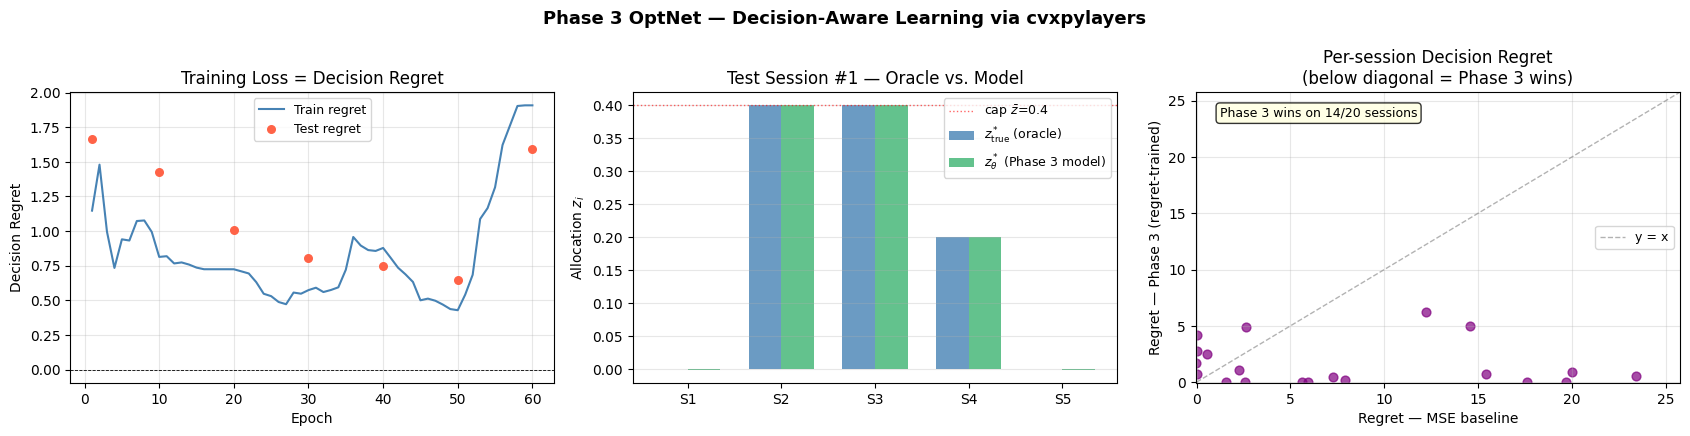

Figure saved to phase3_optnet_training.png


In [8]:
# Cell 8 — Three-panel figure: loss curve, allocation bars, per-session regret scatter

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
fig.suptitle("Phase 3 OptNet — Decision-Aware Learning via cvxpylayers",
             fontsize=13, fontweight="bold")

# ── Panel 1: Loss curve ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(range(1, N_EPOCHS + 1), train_history,
        color="steelblue", linewidth=1.5, label="Train regret")
ep, tr = zip(*test_history)
ax.scatter(ep, tr, color="tomato", s=30, zorder=5, label="Test regret")
ax.set_xlabel("Epoch")
ax.set_ylabel("Decision Regret")
ax.set_title("Training Loss = Decision Regret")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")

# ── Panel 2: Allocation comparison on a sample test session ──────────────────
model_regret.eval()
with torch.no_grad():
    c_pred_t0 = model_regret(X_test[:1])
    (z_pred_t0,) = cvxpy_layer(c_pred_t0)
z_oracle = z_test_true_np[0]
z_model  = z_pred_t0.squeeze(0).numpy()

ax = axes[1]
x_pos = np.arange(N_SUPPLIERS)
w     = 0.35
ax.bar(x_pos - w/2, z_oracle, w, label="$z^*_{\\mathrm{true}}$ (oracle)",
       color="steelblue", alpha=0.8)
ax.bar(x_pos + w/2, z_model,  w, label="$z^*_\\theta$ (Phase 3 model)",
       color="mediumseagreen", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"S{i+1}" for i in range(N_SUPPLIERS)])
ax.set_ylabel("Allocation $z_i$")
ax.set_title("Test Session #1 — Oracle vs. Model")
ax.axhline(MAX_ALLOC, color="red", linestyle=":", linewidth=1, alpha=0.6,
           label=f"cap $\\bar z$={MAX_ALLOC}")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── Panel 3: Per-session test regret scatter (MSE baseline vs. Phase 3) ──────
with torch.no_grad():
    (z_mse_test,)    = cvxpy_layer(model_mse(X_test))
    (z_regret_test,) = cvxpy_layer(model_regret(X_test))
    per_session_mse_regret    = ((c_test * z_mse_test).sum(dim=1)
                                  - optimal_cost_test).numpy()
    per_session_regret_regret = ((c_test * z_regret_test).sum(dim=1)
                                  - optimal_cost_test).numpy()

ax = axes[2]
lim = max(per_session_mse_regret.max(),
          per_session_regret_regret.max(), 1e-3) * 1.1
ax.plot([0, lim], [0, lim], color="gray", linestyle="--", linewidth=1, alpha=0.6,
        label="y = x")
ax.scatter(per_session_mse_regret, per_session_regret_regret,
           color="purple", s=40, alpha=0.7)
ax.set_xlabel("Regret — MSE baseline")
ax.set_ylabel("Regret — Phase 3 (regret-trained)")
ax.set_title("Per-session Decision Regret\n(below diagonal = Phase 3 wins)")
ax.set_xlim(-0.05, lim)
ax.set_ylim(-0.05, lim)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

wins = (per_session_regret_regret < per_session_mse_regret).sum()
ax.text(0.05, 0.95, f"Phase 3 wins on {wins}/{N_TEST} sessions",
        transform=ax.transAxes, fontsize=9, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.savefig("phase3_optnet_training.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved to phase3_optnet_training.png")

## Conclusion: Why Decision-Aware Learning Wins

The MSE baseline minimises a symmetric, scale-uniform error. From its perspective, a 5 % overestimate on a never-selected supplier is just as bad as a 5 % overestimate on the supplier that sits exactly at the LP's allocation boundary. From the **business's** perspective, the first error is free and the second flips a 0.4-fraction allocation to the wrong supplier — potentially tens of thousands of rupees of avoidable cost.

Phase 3 closes this gap by making the loss function *aware* of the downstream solver:

1. The encoder $f_\theta$ outputs predicted costs $\mathbf{c}_\theta$.
2. `cvxpylayers` turns these into an allocation $\mathbf{z}^*_\theta$ via an LP solve.
3. The loss is the **realised financial regret** of using $\mathbf{z}^*_\theta$ instead of the oracle $\mathbf{z}^*_{\text{true}}$.
4. Implicit differentiation of the KKT conditions (the $K_{\text{sym}}$ system) propagates the regret gradient back through the solver to $\theta$ — and PyTorch autograd handles the rest.

### When to Promote Phase 3 to Production

Per the architecture document (`phase3_optnet_e2e.md` §5), the gating criteria are:

- **Data:** ≥ 50,000 closed procurement records with realised cost vectors $\mathbf{c}_{\text{true}}$ in PostgreSQL.
- **Phase 2 plateau:** NDCG@5 improvement < 0.5 % over three monthly retraining cycles.
- **Decision-quality gap:** test regret > 15 % of oracle cost on holdout.
- **Shadow mode:** ≥ one full fiscal quarter monitored via `observability_monitoring`.
- **Counterfactual explanation module** passes `security_compliance` review.
- **Phase 1 fallback** path operational on solver divergence or SLA breach.

### Engineering Cost

End-to-end OptNet pays for its decision-quality gain with:

- LP solve at every forward pass (50–500 ms vs. 1–10 ms for Phase 2 inference).
- Backward pass requires KKT system factorisation: $\mathcal{O}\!\left((n + 2m + p)^3\right)$ per session.
- Loss surface has flat regions where $\partial \mathbf{z}^* / \partial \mathbf{c} = 0$ (interior of optimal face) — AdamW + occasional warm restarts mitigate this.

The architecture document tracks all these costs in `business_impact_metrics` and `technical_performance_metrics`. **This notebook captures only the core mechanic** — implicit differentiation of an embedded LP — that makes the Phase 3 architecture distinct from every shallower learning approach in the roadmap.